In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
import pandas as pd
from astroquery.simbad import Simbad
import astropy.units as u

In [3]:
lk.search_lightcurve('TIC 284898141')

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 21,2020,SPOC,120,284898141,0.0
1,TESS Sector 21,2020,TESS-SPOC,1800,284898141,0.0
2,TESS Sector 47,2021,TESS-SPOC,600,284898141,0.0
3,TESS Sector 21,2020,QLP,1800,284898141,0.0
4,TESS Sector 47,2021,QLP,600,284898141,0.0


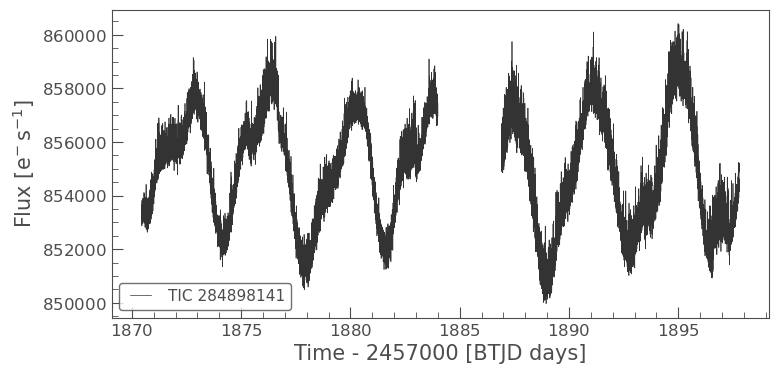

In [4]:
lc = lk.search_lightcurve('TIC 284898141', author="SPOC", exptime=120).download()
lc.plot();

In [5]:
df = lc.to_pandas()
df_lc = df[pd.notnull(df['flux'])]
df_lc

,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,...,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
time,,,,,,,,,,,,,,,,,,,,,
1870.441281,853629.5625,103.895592,0.005515,462946,634.108009,1622.742200,830822.2500,100.952080,15326.103516,23.841866,...,NaN,NaN,NaN,NaN,634.108009,0.000123,1622.742200,0.000143,0.027300,0.112990
1870.442670,853288.8125,103.861862,0.005515,462947,634.109036,1622.741426,830788.1250,100.919296,15234.072266,23.798889,...,NaN,NaN,NaN,NaN,634.109036,0.000123,1622.741426,0.000143,0.027612,0.116511
1870.444059,853061.5625,103.843300,0.005515,462948,634.105902,1622.741090,830388.3125,100.901268,15197.158203,23.834257,...,NaN,NaN,NaN,NaN,634.105902,0.000123,1622.741090,0.000143,0.024127,0.113896
1870.445448,853600.5000,103.853302,0.005516,462949,634.109059,1622.742541,830962.8750,100.910973,15139.267578,23.776073,...,NaN,NaN,NaN,NaN,634.109059,0.000123,1622.742541,0.000143,0.028437,0.115496
1870.446837,853209.0000,103.825249,0.005516,462950,634.107133,1622.741271,830753.9375,100.883728,15094.633789,23.724249,...,NaN,NaN,NaN,NaN,634.107133,0.000123,1622.741271,0.000143,0.026717,0.116147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1897.779769,854140.3125,102.222618,0.005126,482630,634.042952,1622.537533,828036.4375,99.326500,5524.595703,19.721230,...,NaN,NaN,NaN,NaN,634.042952,0.000121,1622.537533,0.000138,-0.042872,-0.141907
1897.781158,855210.3750,102.242043,0.005126,482631,634.045770,1622.533842,828316.6875,99.345375,5547.112305,19.697964,...,NaN,NaN,NaN,NaN,634.045770,0.000121,1622.533842,0.000138,-0.039483,-0.148237
1897.782547,854145.9375,102.215157,0.005126,482632,634.047429,1622.534133,827968.9375,99.319244,5536.235840,19.730618,...,NaN,NaN,NaN,NaN,634.047429,0.000121,1622.534133,0.000138,-0.038066,-0.147599


<function matplotlib.pyplot.show(close=None, block=None)>

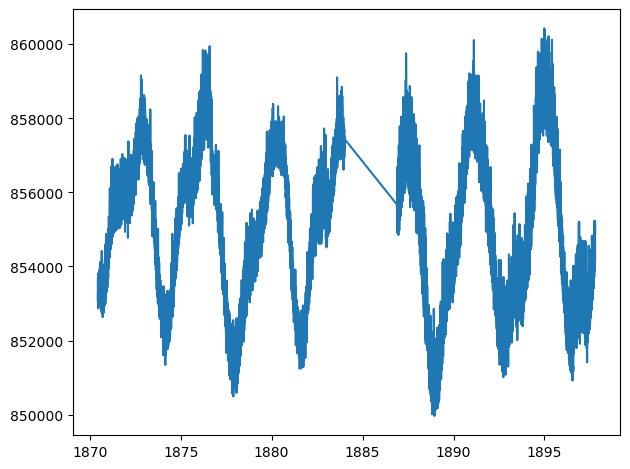

In [6]:
df_lc = df_lc.reset_index(names=['time'])
fig, ax = plt.subplots(tight_layout=True)
ax.plot(df_lc['time'], df_lc['flux'])
plt.show

In [7]:
pg = lc.normalize(unit='ppm').to_periodogram()
pg

C:\Users\ejo08\miniforge3\envs\astro9\Lib\site-packages\astropy\units\quantity.py:648: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


LombScarglePeriodogram(ID: TIC 284898141)

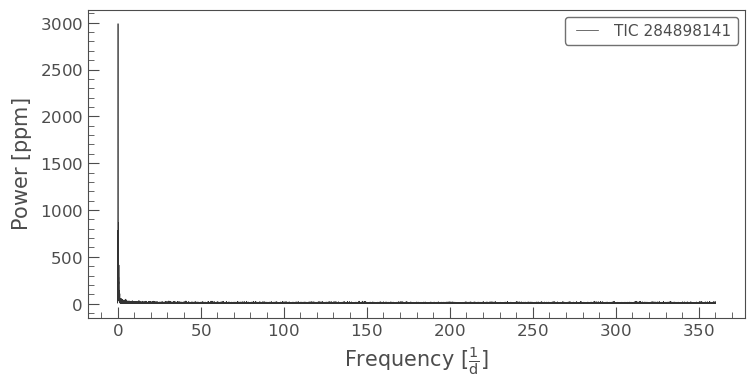

In [8]:
pg.plot();

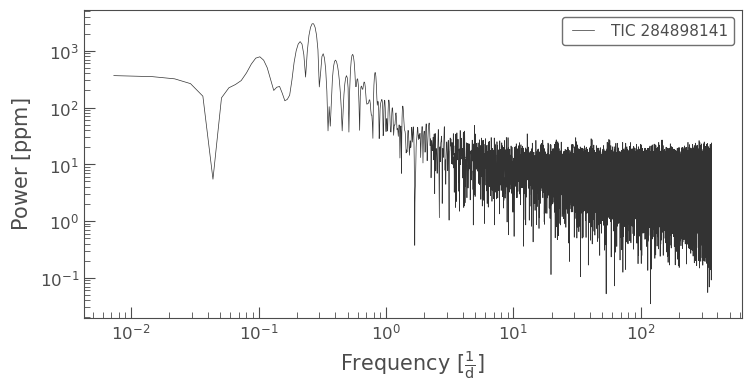

In [9]:
pg.plot(scale='log');

In [10]:
pg.show_properties()

lightkurve.Periodogram properties:
      Attribute         Description   Units
---------------------- -------------- -----
                nterms              1      
              targetid      284898141      
          default_view      frequency      
                 label  TIC 284898141      
             ls_method           fast      
frequency_at_max_power         0.2633 1 / d
             max_power      2989.6271   ppm
               nyquist       360.0058 1 / d
   period_at_max_power         3.7978     d
             frequency array (49220,) 1 / d
                period array (49220,)     d
                 power array (49220,)   ppm
                  meta <class 'dict'>      


In [11]:
period = pg.period_at_max_power
period

<Quantity 3.79778379 d>

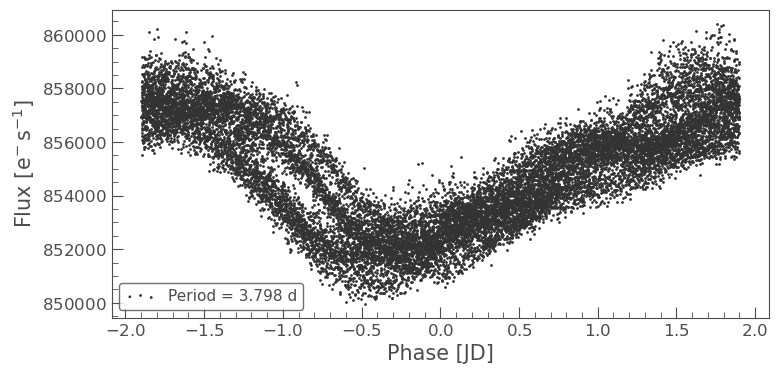

In [12]:
lc.fold(period).scatter(label=f'Period = {period.value:.3f} d');

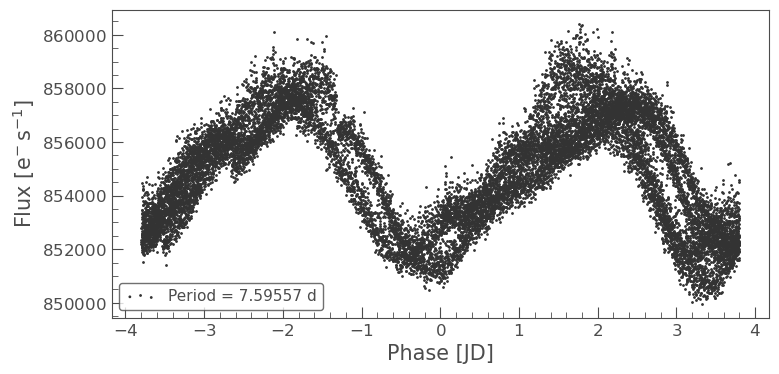

In [13]:
lc.fold(2*period).scatter(label=fr'Period = {2*period.value:.5f} d');

In [14]:
rot_period = period
print(f"Estimated Rotation Period: {rot_period:.2f} days")

Estimated Rotation Period: 3.80 d days


In [16]:
k = 7.59557
age = (rot_period.value / k)**2
print(f"Estimated Age: {age:.2f} Gyr")

Estimated Age: 0.25 Gyr
